In [5]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
# from Q_Seg_main.qseg.dwave_utils import *
from qseg import *
import cv2
from my_segmentation import *
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, recall_score, precision_score
import time
import copy
import pandas as pd
from itertools import product

In [7]:
img_path = "C:/Users/syj43/q_seg/datasets/road_sample/images/"
label_path = "C:/Users/syj43/q_seg/datasets/road_sample/labels/"
img_files = [f for f in os.listdir(img_path)]
label_files = [f for f in os.listdir(label_path)] # ground truth

images = [cv2.imread(img_path+f, cv2.IMREAD_GRAYSCALE) for f in img_files]
masks = [cv2.imread(label_path+f, cv2.IMREAD_GRAYSCALE) for f in label_files]
print(len(images), len(masks))

30 30


In [8]:
def optimize_pipeline_road(raw_image, mask):
    # Match sequential step 1: Sharpen image first
    image = median_blurring(raw_image)
    dim = image.shape[0]

    # Construct base graph once from sharpened image
    start = time.time()
    G_base, dmin, dmax = construct_graph(image)
    end = time.time()
    conversion_time = round(end-start,3)
    
    thresholds = np.arange(0,0.6,0.1)
    k_values = np.arange(0,0.6,0.1)
    close_loop = ['rc', '']
    
    results = []
    
    for th, k, cl in product(thresholds, k_values, close_loop):
        G = copy.deepcopy(G_base)
        
        start = time.time() #
        H, I, important, redundant = importance_sampling(
            G, threshold=th, node_size=0.1, show_graph=False)
        if k > 0:
            sampled_nodes = random_sampling(I, copy.deepcopy(redundant), k=k, seed=0)
            I.add_nodes_from(sampled_nodes)
        I = update_edgeweights(I, image, dim, dmin, dmax, close_loop=cl)
        end = time.time()
        sampling_time = round(end-start,3)

        # solve QUBO
        start = time.time()
        bqm, sampleset = annealer_solver_sa(I)
        sampleset_first = sampleset.first.sample
        end = time.time()
        annealing_time = round(end-start,3)

        # label propagation
        metrics_df, labeling_time = show_results_runtime(sampleset_first, I, mask, dim, show_graph=False)
        labeling_time = round(labeling_time, 3) ##
        
        results.append({
            'thresholds':th,
            'k_values':k,
            'close_loop':cl,
            'Accuracy': metrics_df['accuracy'].iloc[0],
            'IoU': metrics_df['iou'].iloc[0],
            'Precision': metrics_df['precision'].iloc[0],
            'Recall': metrics_df['recall'].iloc[0],
            'F1': metrics_df['f1'].iloc[0],
            'Conversion time': conversion_time,
            'Sampling time' : sampling_time,
            'Annealing time' : annealing_time,
            'Labeling time' : labeling_time

        })
        
    df_results = pd.DataFrame(results)
    best_config = df_results.sort_values(by='IoU', ascending=False).iloc[0]

    return best_config

In [37]:
i = 0
optimize_pipeline_road(images[i], masks[i])

thresholds           0.5
k_values             0.5
close_loop            rc
Accuracy           0.978
IoU                0.724
Precision          0.835
Recall             0.796
F1                 0.814
Conversion time    0.799
Sampling time      0.341
Annealing time     3.307
Labeling time      2.073
Name: 70, dtype: object

In [9]:
df = pd.DataFrame(columns=['idx', 'thresholds', 'k', 'cl', 'Accuracy', 'IoU', 'Precision', 'Recall', 'F1', 'Conversion time', 'Sampling time', 'Annealing time', 'Labeling time'])

In [12]:
for i in range(len(images)):  
    best_config = optimize_pipeline_road(images[i], masks[i])
    df.loc[len(df)] = [i] + best_config.tolist()
    
df

,idx,thresholds,k,cl,Accuracy,IoU,Precision,Recall,F1,Conversion time,Sampling time,Annealing time,Labeling time
0,0,0.5,0.4,rc,0.978,0.722,0.842,0.787,0.812,0.687,0.319,2.900,2.008
1,1,0.4,0.4,rc,0.960,0.662,0.972,0.683,0.757,0.820,0.346,4.410,2.006
2,2,0.4,0.5,,0.975,0.739,0.939,0.765,0.828,0.676,0.295,1.413,2.001
3,3,0.5,0.3,rc,0.895,0.590,0.655,0.799,0.695,0.807,0.342,4.447,2.031
4,4,0.4,0.3,rc,0.984,0.870,0.933,0.920,0.926,0.677,0.313,2.087,1.998
5,5,0.5,0.4,rc,0.965,0.709,0.738,0.933,0.803,0.671,0.401,8.846,2.124
6,6,0.4,0.4,rc,0.967,0.674,0.789,0.750,0.768,0.683,0.307,2.087,1.984
7,7,0.4,0.0,,0.959,0.695,0.898,0.733,0.791,0.680,0.238,1.509,2.038
8,8,0.5,0.5,rc,0.933,0.609,0.666,0.783,0.705,0.670,0.317,2.453,1.784
9,9,0.3,0.3,,0.974,0.733,0.814,0.833,0.823,0.815,0.291,1.266,2.021


In [13]:
df.to_csv('road_this_work.csv', index=False)

In [14]:
df = pd.read_csv('road_this_work.csv', index_col=False)
df.fillna(0)

,idx,thresholds,k,cl,Accuracy,IoU,Precision,Recall,F1,Conversion time,Sampling time,Annealing time,Labeling time
0,0,0.5,0.4,rc,0.978,0.722,0.842,0.787,0.812,0.687,0.319,2.900,2.008
1,1,0.4,0.4,rc,0.960,0.662,0.972,0.683,0.757,0.820,0.346,4.410,2.006
2,2,0.4,0.5,0,0.975,0.739,0.939,0.765,0.828,0.676,0.295,1.413,2.001
3,3,0.5,0.3,rc,0.895,0.590,0.655,0.799,0.695,0.807,0.342,4.447,2.031
4,4,0.4,0.3,rc,0.984,0.870,0.933,0.920,0.926,0.677,0.313,2.087,1.998
5,5,0.5,0.4,rc,0.965,0.709,0.738,0.933,0.803,0.671,0.401,8.846,2.124
6,6,0.4,0.4,rc,0.967,0.674,0.789,0.750,0.768,0.683,0.307,2.087,1.984
7,7,0.4,0.0,0,0.959,0.695,0.898,0.733,0.791,0.680,0.238,1.509,2.038
8,8,0.5,0.5,rc,0.933,0.609,0.666,0.783,0.705,0.670,0.317,2.453,1.784
9,9,0.3,0.3,0,0.974,0.733,0.814,0.833,0.823,0.815,0.291,1.266,2.021


In [15]:
df.describe().loc[['mean', '50%']].round(3)

,idx,thresholds,k,Accuracy,IoU,Precision,Recall,F1,Conversion time,Sampling time,Annealing time,Labeling time
mean,14.5,0.41,0.353,0.965,0.738,0.850,0.833,0.824,0.73,0.328,3.596,2.001
50%,14.5,0.40,0.400,0.973,0.734,0.884,0.820,0.824,0.68,0.318,2.707,2.015


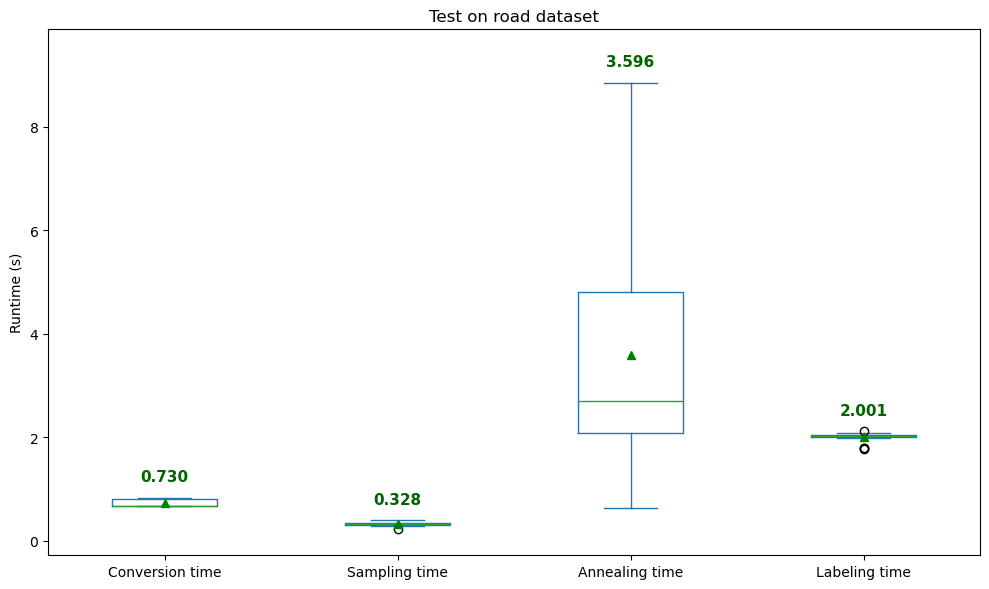

In [16]:
if 'idx' in df.columns:
    df_runtime = df.set_index('idx')
df_runtime = df_runtime[['Conversion time', 'Sampling time', 'Annealing time', 'Labeling time']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on road dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

In [17]:
df.drop(columns=['idx', 'thresholds', 'k', 'cl', 'Conversion time', 'Sampling time', 'Annealing time', 'Labeling time'], inplace=True)

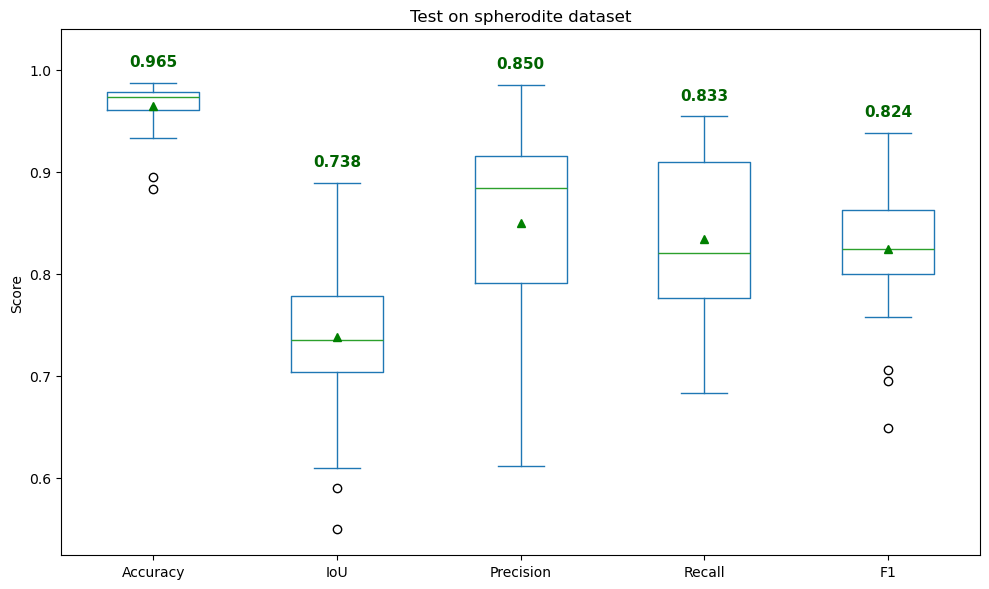

In [18]:
# df.drop(columns=['Runtime'], inplace=True)

# 1. Generate boxplot with mean markers
ax = df.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df.values.max() - df.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df.columns, start=1):
    mean_val = df[col].mean()
    max_val = df[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df.values.min() - y_offset * 2, df.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

QUBO w/o sampling

In [ ]:
results_qubo = []

for i in range(len(images)):
    sample = sharpnening(images[i])
    dim = sample.shape[0]

    start = time.time()
    G, dmin, dmax = construct_graph(sample)
    end = time.time()
    conversion_time = round(end-start,3)

    start = time.time()
    bqm, sampleset = annealer_solver_sa(G)
    sampleset_first = sampleset.first.sample
    end = time.time()
    annealing_time = round(end-start,3)
    
    accuracy, iou, precision, recall, f1 = qseg_evaluation(sampleset_first, dim, masks[i])
    
    results_qubo.append({
        'Accuracy': accuracy,
        'IoU': iou,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Conversion time': conversion_time,
        'Annealing time' : annealing_time,
    })

df_qubo = pd.DataFrame(results_qubo)
df_qubo

In [ ]:
df_qubo.to_csv('road_qubo.csv', index=False)

In [26]:
df_qubo = pd.read_csv('road_qubo.csv')

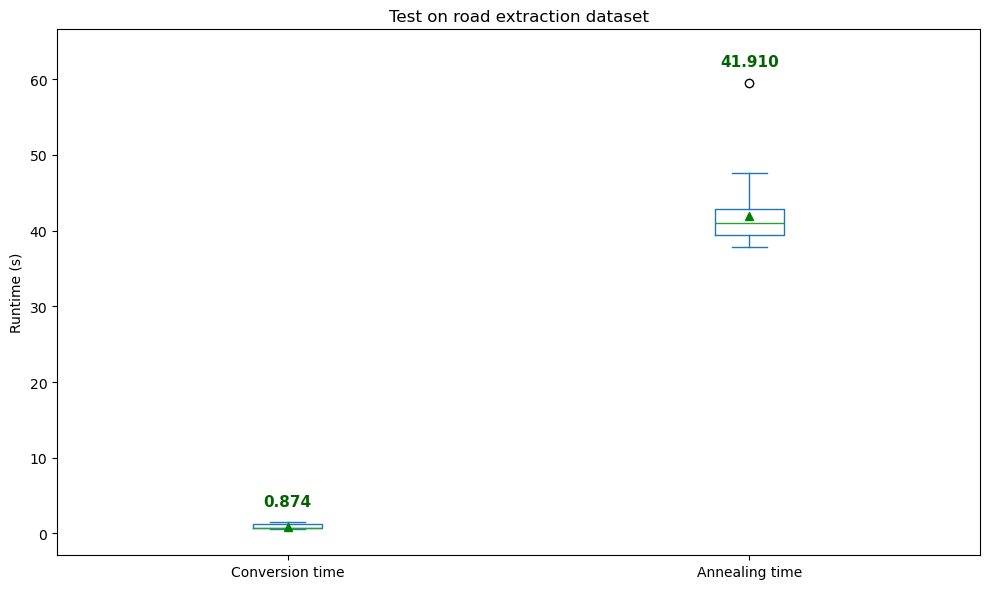

In [27]:
if 'idx' in df_qubo.columns:
    df_qubo = df_qubo.set_index('idx')

df_runtime = df_qubo[['Conversion time', 'Annealing time']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on road extraction dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

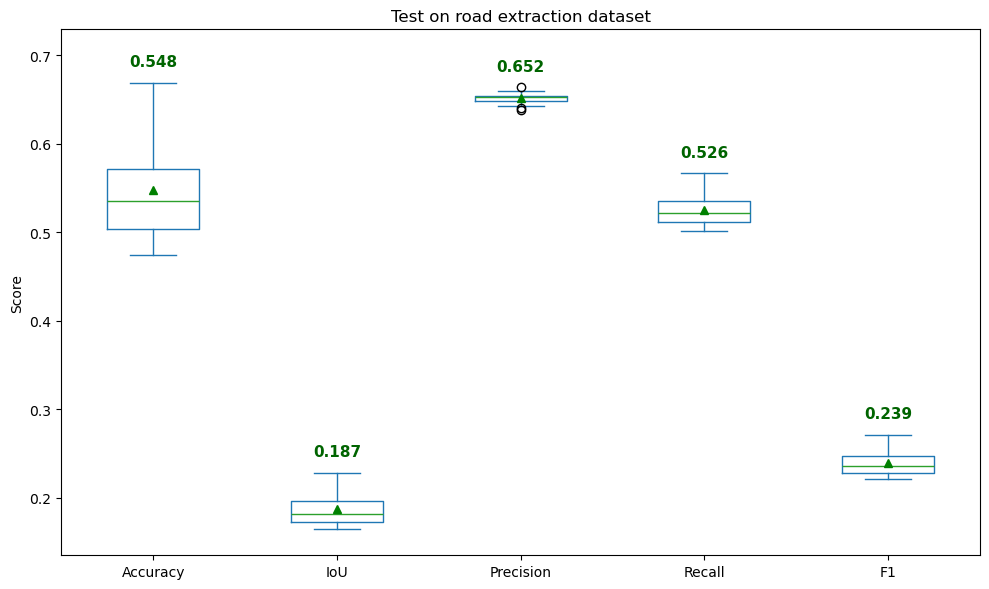

In [24]:
# df_qubo.drop(columns=['Annealing time', 'Conversion time'], inplace=True)

# 1. Generate boxplot with mean markers
ax = df_qubo.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_qubo.values.max() - df_qubo.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_qubo.columns, start=1):
    mean_val = df_qubo[col].mean()
    max_val = df_qubo[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_qubo.values.min() - y_offset * 2, df_qubo.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on road extraction dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()